## Brightness identifier

Mean Brightness: 126.20


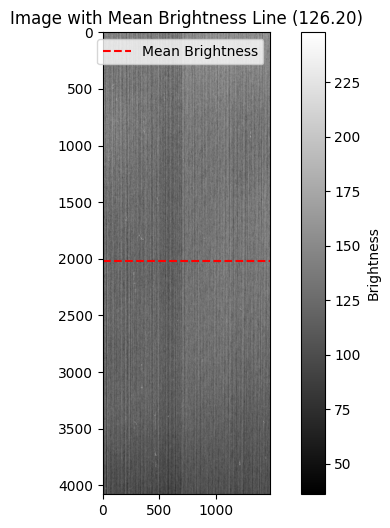

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img_path = "csb.JPG"
img = cv2.imread(img_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Calculate mean brightness
mean_brightness = np.mean(gray)
print(f"Mean Brightness: {mean_brightness:.2f}")

# Plot the image and mean brightness line
plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap='gray')
plt.title(f"Image with Mean Brightness Line ({mean_brightness:.2f})")
plt.colorbar(label="Brightness")

# Plot horizontal line marking the mean brightness
plt.axhline(y=mean_brightness / 255 * gray.shape[0], color='red', linestyle='--', label='Mean Brightness')
plt.legend()
plt.show()


## columnwise brightness

Overall Mean Brightness: 181.22


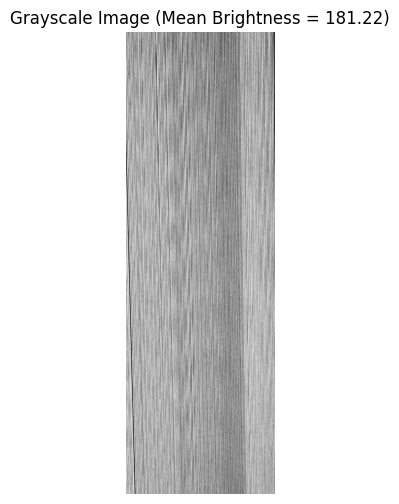

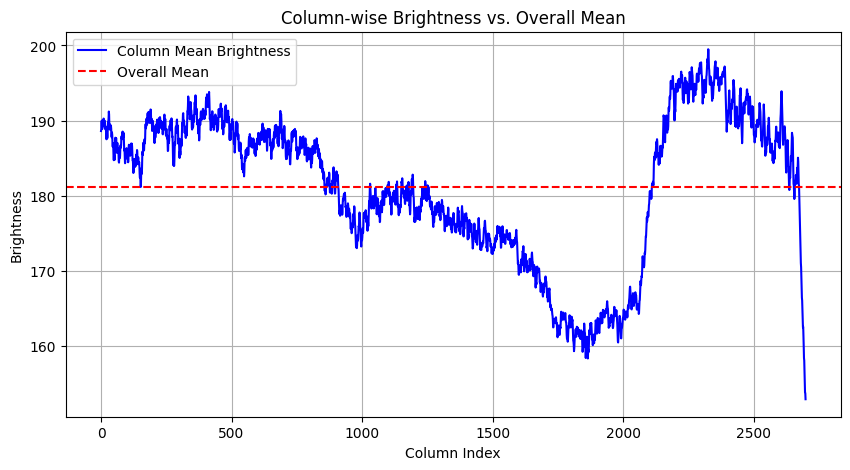

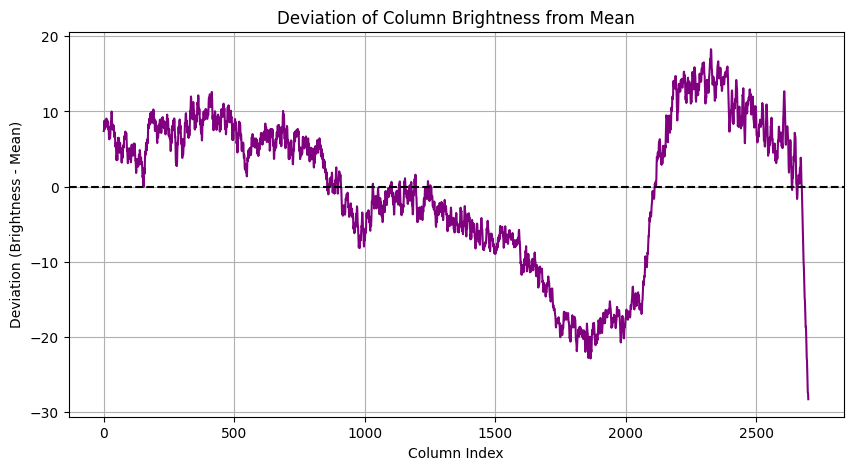

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load and preprocess image ---
img_path = "csb1.JPG"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- Compute overall mean brightness ---
mean_brightness = np.mean(gray)
print(f"Overall Mean Brightness: {mean_brightness:.2f}")

# --- Compute column-wise mean brightness ---
column_means = np.mean(gray, axis=0)

# --- Compute deviation of each column from overall mean ---
deviation = column_means - mean_brightness

# --- Plot 1: Grayscale image ---
plt.figure(figsize=(10, 6))
plt.imshow(gray, cmap='gray')
plt.title(f"Grayscale Image (Mean Brightness = {mean_brightness:.2f})")
plt.axis("off")
plt.show()

# --- Plot 2: Column brightness & mean line ---
plt.figure(figsize=(10, 5))
plt.plot(column_means, label='Column Mean Brightness', color='blue')
plt.axhline(y=mean_brightness, color='red', linestyle='--', label='Overall Mean')
plt.title("Column-wise Brightness vs. Overall Mean")
plt.xlabel("Column Index")
plt.ylabel("Brightness")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 3: Deviation of each column from the mean ---
plt.figure(figsize=(10, 5))
plt.plot(deviation, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Deviation of Column Brightness from Mean")
plt.xlabel("Column Index")
plt.ylabel("Deviation (Brightness - Mean)")
plt.grid(True)
plt.show()


## Column wise Brightness log

In [4]:
import cv2
import numpy as np
import pandas as pd
from scipy import stats

# ----------------------------
# CONFIG
# ----------------------------
img_path = "csbv2.JPG"
column_width = 15
window_size = 5   # for local means
output_xlsx = "column_brightness_log.xlsx"

# ----------------------------
# LOAD IMAGE
# ----------------------------
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError("Image not found at:", img_path)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

# ----------------------------
# COMPUTE COLUMN MEANS
# ----------------------------
num_cols = w // column_width
column_means = []

for i in range(num_cols):
    start = i * column_width
    end = min((i + 1) * column_width, w)
    block = gray[:, start:end]
    column_means.append(np.mean(block))

column_means = np.array(column_means)

# ----------------------------
# GLOBAL MEAN & MODE
# ----------------------------
global_mean = float(np.mean(gray))
mode_res = stats.mode(gray.flatten(), keepdims=True)
global_mode = float(mode_res.mode[0])

# ----------------------------
# LOCAL MEANS (Sliding Window)
# ----------------------------
half_w = window_size // 2
local_means = []

for i in range(num_cols):
    s = max(0, i - half_w)
    e = min(num_cols, i + half_w + 1)
    local_means.append(np.mean(column_means[s:e]))

local_means = np.array(local_means)

# ----------------------------
# SAVE TO EXCEL (.xlsx)
# ----------------------------
df = pd.DataFrame({
    "Column_Index": np.arange(num_cols),
    "Column_Mean_Brightness": column_means,
    "Local_Mean_Brightness": local_means,
    "Global_Mean": [global_mean] * num_cols,
    "Global_Mode": [global_mode] * num_cols
})

df.to_excel(output_xlsx, index=False)
print(f"\nExcel file saved successfully as: {output_xlsx}")


Excel file saved successfully as: column_brightness_log.xlsx


## Deviation calculation with bounding box

Overall Mean Brightness: 181.22


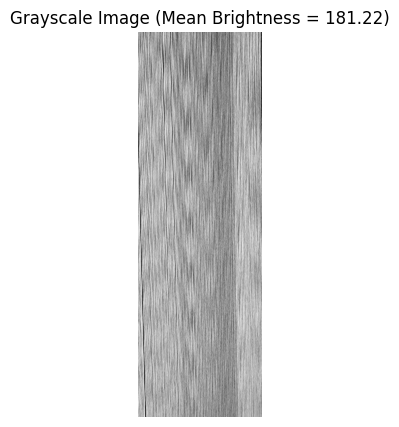

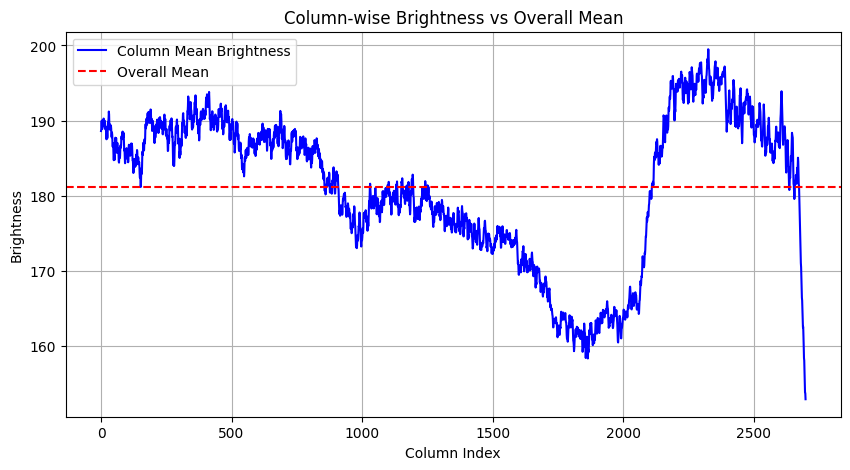

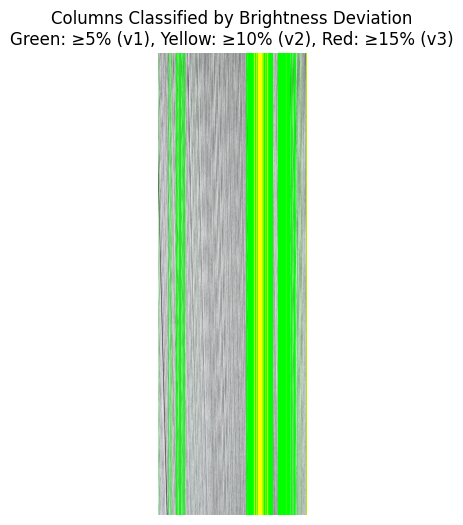

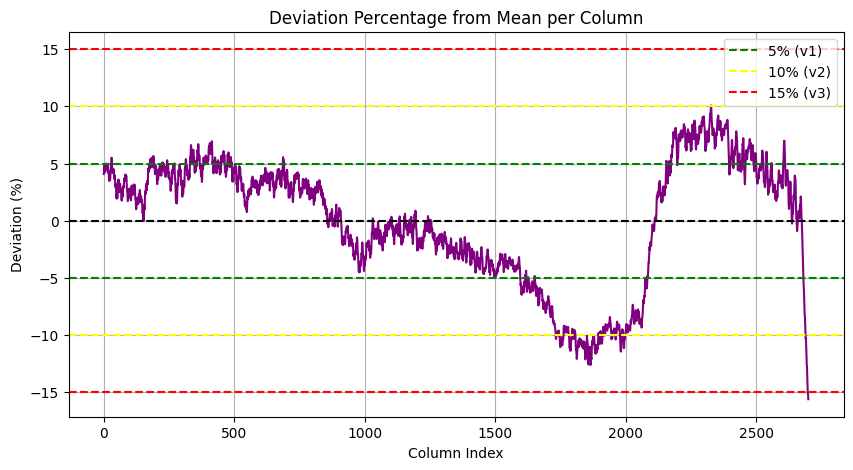

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load and preprocess image ---
img_path = "csb1.JPG"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

# --- Compute overall mean brightness ---
mean_brightness = np.mean(gray)
print(f"Overall Mean Brightness: {mean_brightness:.2f}")

# --- Compute column-wise mean brightness ---
column_means = np.mean(gray, axis=0)

# --- Compute deviation percentage from mean ---
deviation_percent = ((column_means - mean_brightness) / mean_brightness) * 100

# --- Classification thresholds ---
v1_threshold = 5
v2_threshold = 10
v3_threshold = 15

# --- Create a copy of the original image to draw on ---
output_img = img.copy()

# --- Colors for categories (BGR) ---
colors = {
    'v1': (0, 255, 0),   # Green
    'v2': (0, 255, 255), # Yellow
    'v3': (0, 0, 255)    # Red
}

# --- Classify each column and draw bounding boxes ---
for i, dev in enumerate(deviation_percent):
    abs_dev = abs(dev)
    if abs_dev >= v3_threshold:
        category = 'v3'
        color = colors[category]
    elif abs_dev >= v2_threshold:
        category = 'v2'
        color = colors[category]
    elif abs_dev >= v1_threshold:
        category = 'v1'
        color = colors[category]
    else:
        continue  # skip small deviations

    # Draw a vertical bounding box for that column
    cv2.rectangle(output_img, (i, 0), (i+1, h), color, 1)

# --- Plot 1: Original grayscale image ---
plt.figure(figsize=(10, 5))
plt.imshow(gray, cmap='gray')
plt.title(f"Grayscale Image (Mean Brightness = {mean_brightness:.2f})")
plt.axis("off")
plt.show()

# --- Plot 2: Column brightness with mean ---
plt.figure(figsize=(10, 5))
plt.plot(column_means, color='blue', label='Column Mean Brightness')
plt.axhline(y=mean_brightness, color='red', linestyle='--', label='Overall Mean')
plt.title("Column-wise Brightness vs Overall Mean")
plt.xlabel("Column Index")
plt.ylabel("Brightness")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 3: Classified columns with bounding boxes ---
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title("Columns Classified by Brightness Deviation\nGreen: ≥5% (v1), Yellow: ≥10% (v2), Red: ≥15% (v3)")
plt.axis("off")
plt.show()

# --- Plot 4: Deviation percentage graph ---
plt.figure(figsize=(10, 5))
plt.plot(deviation_percent, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=v1_threshold, color='green', linestyle='--', label='5% (v1)')
plt.axhline(y=-v1_threshold, color='green', linestyle='--')
plt.axhline(y=v2_threshold, color='yellow', linestyle='--', label='10% (v2)')
plt.axhline(y=-v2_threshold, color='yellow', linestyle='--')
plt.axhline(y=v3_threshold, color='red', linestyle='--', label='15% (v3)')
plt.axhline(y=-v3_threshold, color='red', linestyle='--')
plt.title("Deviation Percentage from Mean per Column")
plt.xlabel("Column Index")
plt.ylabel("Deviation (%)")
plt.legend()
plt.grid(True)
plt.show()


## Final Evenness

Overall Mean Brightness: 123.51

=== Defect Region Summary (≥10 consecutive columns) ===
V1: 3 defect region(s)
V2: 1 defect region(s)
V3: 0 defect region(s)


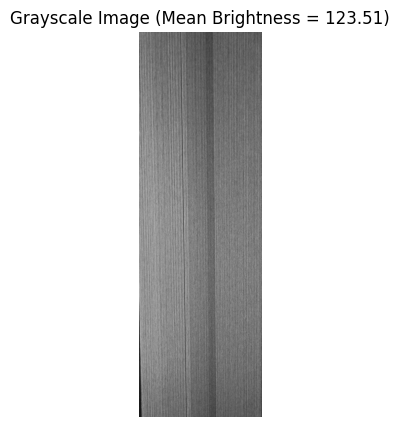

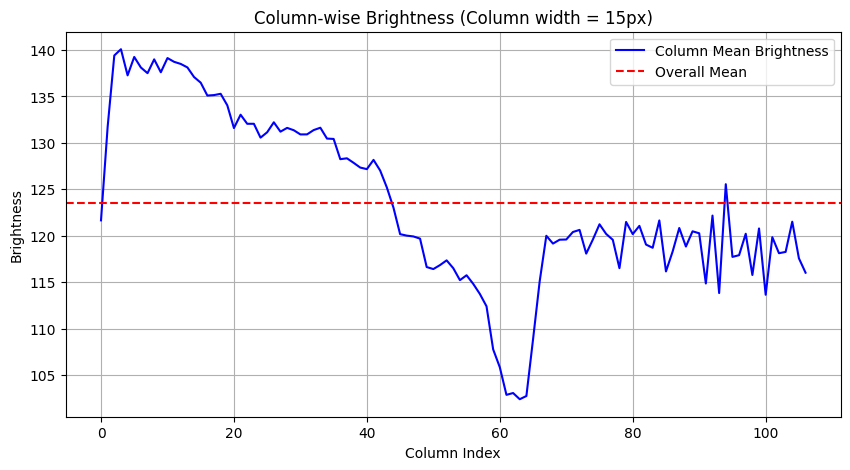

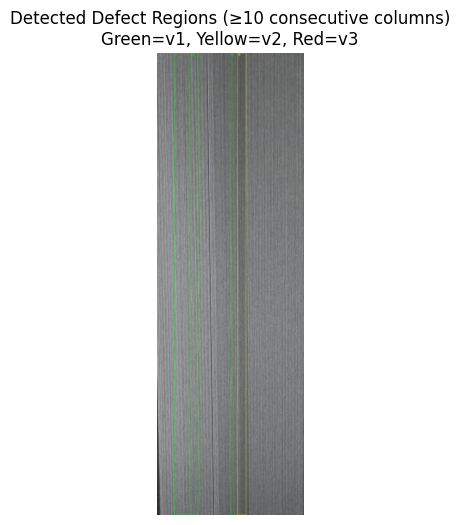

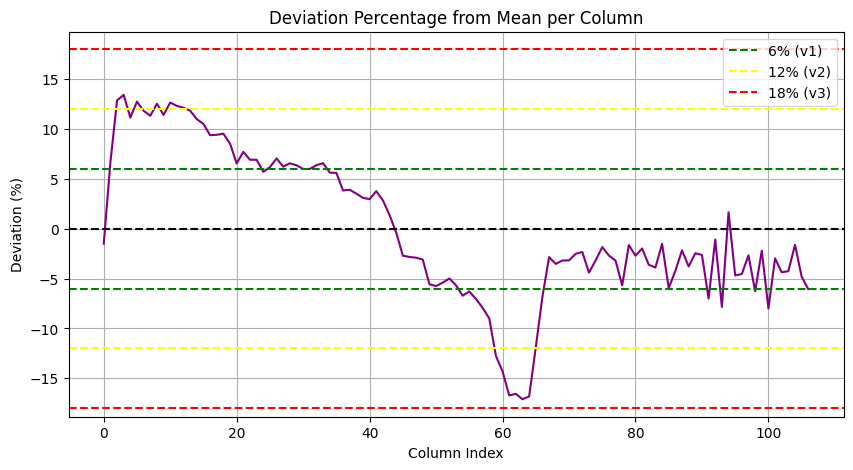

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load and preprocess image ---
img_path = "csbv2a.JPG"   # change if needed
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

# --- Adjustable column width ---
column_width = 15  # Increase this to widen each column before computing mean

# --- Recalculate number of columns based on width ---
num_cols = w // column_width

# --- Compute column-wise mean brightness with wider columns ---
column_means = []
for i in range(num_cols):
    start = i * column_width
    end = min((i + 1) * column_width, w)
    col_mean = np.mean(gray[:, start:end])
    column_means.append(col_mean)

column_means = np.array(column_means)

# --- Compute overall mean brightness ---
mean_brightness = np.mean(gray)
print(f"Overall Mean Brightness: {mean_brightness:.2f}")

# --- Compute deviation percentage from mean ---
deviation_percent = ((column_means - mean_brightness) / mean_brightness) * 100

# --- Classification thresholds ---
v1_threshold = 6
v2_threshold = 12
v3_threshold = 18

# --- Define colors and class priority ---
colors = {
    'v1': (0, 255, 0),   # Green
    'v2': (0, 255, 255), # Yellow
    'v3': (0, 0, 255)    # Red
}
priority = {'v1': 1, 'v2': 2, 'v3': 3}

# --- Classify columns ---
def classify(dev):
    abs_dev = abs(dev)
    if abs_dev >= v3_threshold:
        return 'v3'
    elif abs_dev >= v2_threshold:
        return 'v2'
    elif abs_dev >= v1_threshold:
        return 'v1'
    else:
        return None

column_classes = [classify(dev) for dev in deviation_percent]

# --- Merge adjacent columns of the same class ---
regions = []
start = None
current_class = None

for i in range(num_cols):
    c = column_classes[i]
    if c != current_class:
        if current_class is not None:
            regions.append((start, i - 1, current_class))
        start = i if c is not None else None
        current_class = c
# close the last region
if current_class is not None:
    regions.append((start, num_cols - 1, current_class))

# --- Apply minimum region length condition (10 consecutive columns) ---
min_cols_for_defect = 5
filtered_regions = [
    (start, end, cls)
    for start, end, cls in regions
    if (end - start + 1) >= min_cols_for_defect
]

# --- Resolve overlapping boxes: keep only highest-priority class ---
final_classes = [None] * num_cols
for start, end, cls in filtered_regions:
    for i in range(start, end + 1):
        if final_classes[i] is None or priority[cls] > priority.get(final_classes[i], 0):
            final_classes[i] = cls

# --- Rebuild final regions after overlap resolution ---
final_regions = []
start = None
current_class = None
for i in range(num_cols):
    c = final_classes[i]
    if c != current_class:
        if current_class is not None:
            final_regions.append((start, i - 1, current_class))
        start = i if c is not None else None
        current_class = c
if current_class is not None:
    final_regions.append((start, num_cols - 1, current_class))

# --- Draw final bounding boxes ---
output_img = img.copy()
class_counts = {'v1': 0, 'v2': 0, 'v3': 0}

for start, end, cls in final_regions:
    color = colors[cls]
    x1 = start * column_width
    x2 = min((end + 1) * column_width, w - 1)
    cv2.rectangle(output_img, (x1, 0), (x2, h - 1), color, 2)
    class_counts[cls] += 1
    cv2.putText(output_img, cls.upper(), (x1 + 5, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# --- Print defect statistics ---
print("\n=== Defect Region Summary (≥10 consecutive columns) ===")
for cls, count in class_counts.items():
    print(f"{cls.upper()}: {count} defect region(s)")

# --- Plot 1: Grayscale image ---
plt.figure(figsize=(10, 5))
plt.imshow(gray, cmap='gray')
plt.title(f"Grayscale Image (Mean Brightness = {mean_brightness:.2f})")
plt.axis("off")
plt.show()

# --- Plot 2: Column brightness with mean ---
plt.figure(figsize=(10, 5))
plt.plot(column_means, color='blue', label='Column Mean Brightness')
plt.axhline(y=mean_brightness, color='red', linestyle='--', label='Overall Mean')
plt.title(f"Column-wise Brightness (Column width = {column_width}px)")
plt.xlabel("Column Index")
plt.ylabel("Brightness")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 3: Classified bounding boxes ---
output_path = "detected_defects1.jpg"
cv2.imwrite(output_path, output_img)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Defect Regions (≥10 consecutive columns)\nGreen=v1, Yellow=v2, Red=v3")
plt.axis("off")
plt.show()

# --- Plot 4: Deviation percentage graph ---
plt.figure(figsize=(10, 5))
plt.plot(deviation_percent, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=v1_threshold, color='green', linestyle='--', label='6% (v1)')
plt.axhline(y=-v1_threshold, color='green', linestyle='--')
plt.axhline(y=v2_threshold, color='yellow', linestyle='--', label='12% (v2)')
plt.axhline(y=-v2_threshold, color='yellow', linestyle='--')
plt.axhline(y=v3_threshold, color='red', linestyle='--', label='18% (v3)')
plt.axhline(y=-v3_threshold, color='red', linestyle='--')
plt.title("Deviation Percentage from Mean per Column")
plt.xlabel("Column Index")
plt.ylabel("Deviation (%)")
plt.legend()
plt.grid(True)
plt.show()


## Sliding window


=== Sliding Window Statistics Results ===
Window size: 15, Column width: 10
V1: 16 region(s)
V2: 0 region(s)
V3: 0 region(s)


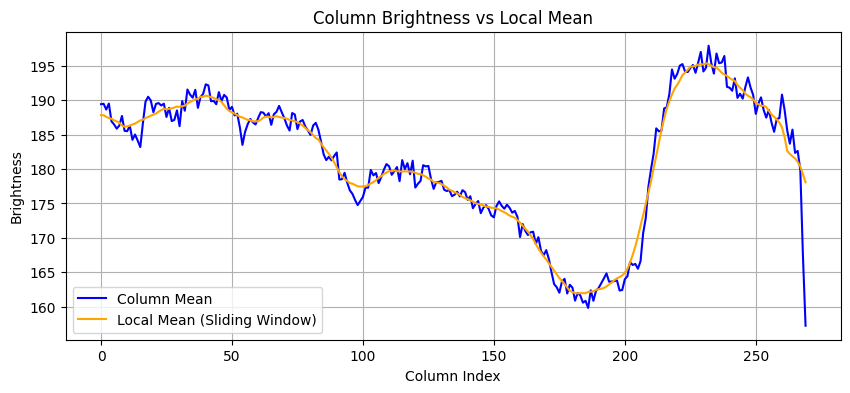

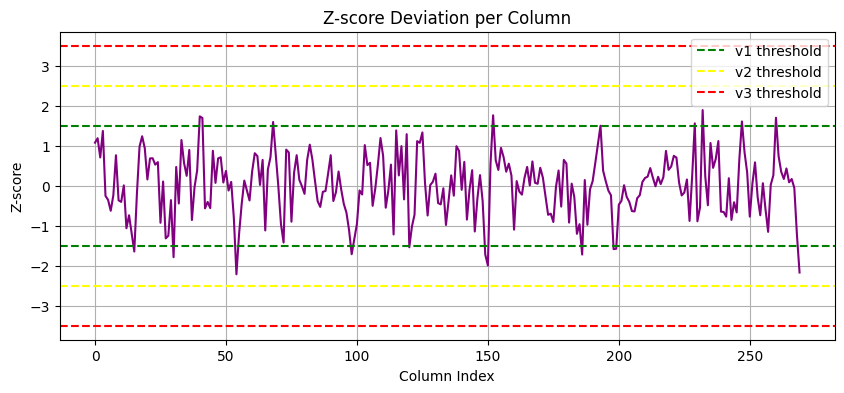

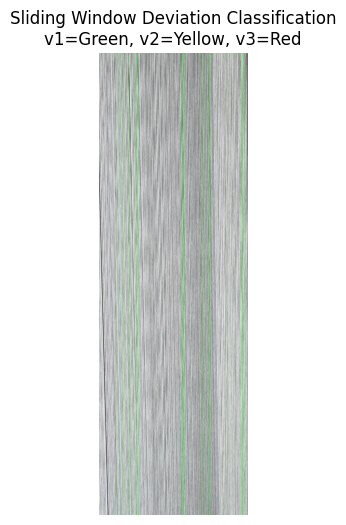

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load and preprocess image ---
img_path = "csb1.JPG"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

# --- Adjustable column width ---
column_width = 10  # width of column block
num_cols = w // column_width

# --- Compute column means (block-based) ---
column_means = []
for i in range(num_cols):
    start = i * column_width
    end = min((i + 1) * column_width, w)
    col_mean = np.mean(gray[:, start:end])
    column_means.append(col_mean)
column_means = np.array(column_means)

# --- Sliding Window Statistics (local normalization) ---
window_size = 15  # number of neighboring columns for local stats
half_w = window_size // 2

# Compute local mean and std for each column
local_means = []
local_stds = []
for i in range(num_cols):
    start = max(0, i - half_w)
    end = min(num_cols, i + half_w + 1)
    local_region = column_means[start:end]
    local_means.append(np.mean(local_region))
    local_stds.append(np.std(local_region))

local_means = np.array(local_means)
local_stds = np.array(local_stds)

# --- Compute Z-score deviation for each column ---
z_scores = np.zeros(num_cols)
for i in range(num_cols):
    if local_stds[i] > 1e-5:
        z_scores[i] = (column_means[i] - local_means[i]) / local_stds[i]
    else:
        z_scores[i] = 0

# --- Classification thresholds (in Z-score units) ---
v1_threshold = 1.5
v2_threshold = 2.5
v3_threshold = 3.5

# --- Define colors and class priority ---
colors = {
    'v1': (0, 255, 0),
    'v2': (0, 255, 255),
    'v3': (0, 0, 255)
}
priority = {'v1': 1, 'v2': 2, 'v3': 3}

# --- Classify columns based on Z-score magnitude ---
def classify_z(z):
    abs_z = abs(z)
    if abs_z >= v3_threshold:
        return 'v3'
    elif abs_z >= v2_threshold:
        return 'v2'
    elif abs_z >= v1_threshold:
        return 'v1'
    else:
        return None

column_classes = [classify_z(z) for z in z_scores]

# --- Merge adjacent columns of the same class ---
regions = []
start = None
current_class = None
for i in range(num_cols):
    c = column_classes[i]
    if c != current_class:
        if current_class is not None:
            regions.append((start, i - 1, current_class))
        start = i if c is not None else None
        current_class = c
if current_class is not None:
    regions.append((start, num_cols - 1, current_class))

# --- Resolve overlaps by priority ---
final_classes = [None] * num_cols
for start, end, cls in regions:
    for i in range(start, end + 1):
        if final_classes[i] is None or priority[cls] > priority.get(final_classes[i], 0):
            final_classes[i] = cls

# --- Rebuild merged boxes after overlap resolution ---
final_regions = []
start = None
current_class = None
for i in range(num_cols):
    c = final_classes[i]
    if c != current_class:
        if current_class is not None:
            final_regions.append((start, i - 1, current_class))
        start = i if c is not None else None
        current_class = c
if current_class is not None:
    final_regions.append((start, num_cols - 1, current_class))

# --- Draw bounding boxes ---
output_img = img.copy()
class_counts = {'v1': 0, 'v2': 0, 'v3': 0}

for start, end, cls in final_regions:
    color = colors[cls]
    x1 = start * column_width
    x2 = min((end + 1) * column_width, w - 1)
    cv2.rectangle(output_img, (x1, 0), (x2, h - 1), color, 2)
    class_counts[cls] += 1
    cv2.putText(output_img, cls.upper(), (x1 + 5, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# --- Print results ---
print("\n=== Sliding Window Statistics Results ===")
print(f"Window size: {window_size}, Column width: {column_width}")
for cls, count in class_counts.items():
    print(f"{cls.upper()}: {count} region(s)")

# --- Plots ---
plt.figure(figsize=(10, 4))
plt.plot(column_means, color='blue', label='Column Mean')
plt.plot(local_means, color='orange', label='Local Mean (Sliding Window)')
plt.title("Column Brightness vs Local Mean")
plt.xlabel("Column Index")
plt.ylabel("Brightness")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(z_scores, color='purple')
plt.axhline(y=v1_threshold, color='green', linestyle='--', label='v1 threshold')
plt.axhline(y=v2_threshold, color='yellow', linestyle='--', label='v2 threshold')
plt.axhline(y=v3_threshold, color='red', linestyle='--', label='v3 threshold')
plt.axhline(y=-v1_threshold, color='green', linestyle='--')
plt.axhline(y=-v2_threshold, color='yellow', linestyle='--')
plt.axhline(y=-v3_threshold, color='red', linestyle='--')
plt.title("Z-score Deviation per Column")
plt.xlabel("Column Index")
plt.ylabel("Z-score")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title("Sliding Window Deviation Classification\nv1=Green, v2=Yellow, v3=Red")
plt.axis("off")
plt.show()


## Mass processing

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

# === CONFIGURATION ===
folder_path = r"Evenness/Standard"  # 🔹 change this to your folder path
output_csv = "brightness_summary.csv"     # optional output table file
column_width = 15                         # width of each analysis column
v1_threshold = 5
v2_threshold = 8
v3_threshold = 11
save_plots = True                         # save plots for each image

# --- Colors and thresholds ---
colors = {
    'v1': (0, 255, 0),
    'v2': (0, 255, 255),
    'v3': (0, 0, 255)
}
priority = {'v1': 1, 'v2': 2, 'v3': 3}

def classify(dev):
    abs_dev = abs(dev)
    if abs_dev >= v3_threshold:
        return 'v3'
    elif abs_dev >= v2_threshold:
        return 'v2'
    elif abs_dev >= v1_threshold:
        return 'v1'
    else:
        return None

# --- Create output directory for plots ---
plot_dir = os.path.join(folder_path, "output_plots")
os.makedirs(plot_dir, exist_ok=True)

# --- Initialize summary table ---
summary_data = []

# --- Iterate through images in folder ---
for filename in os.listdir(folder_path):
    if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        continue

    img_path = os.path.join(folder_path, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Could not read image: {filename}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # --- Compute column means ---
    num_cols = w // column_width
    column_means = []
    for i in range(num_cols):
        start = i * column_width
        end = min((i + 1) * column_width, w)
        column_means.append(np.mean(gray[:, start:end]))
    column_means = np.array(column_means)

    # --- Compute overall mean brightness ---
    mean_brightness = np.mean(gray)

    # --- Compute deviation percentage from mean ---
    deviation_percent = ((column_means - mean_brightness) / mean_brightness) * 100
    max_dev = np.max(np.abs(deviation_percent))

    # --- Classify each column ---
    column_classes = [classify(dev) for dev in deviation_percent]

    # --- Merge adjacent same-class regions ---
    regions = []
    start = None
    current_class = None
    for i in range(num_cols):
        c = column_classes[i]
        if c != current_class:
            if current_class is not None:
                regions.append((start, i - 1, current_class))
            start = i if c is not None else None
            current_class = c
    if current_class is not None:
        regions.append((start, num_cols - 1, current_class))

    # --- Resolve overlapping by class priority ---
    final_classes = [None] * num_cols
    for start, end, cls in regions:
        for i in range(start, end + 1):
            if final_classes[i] is None or priority[cls] > priority.get(final_classes[i], 0):
                final_classes[i] = cls

    # --- Rebuild merged boxes ---
    final_regions = []
    start = None
    current_class = None
    for i in range(num_cols):
        c = final_classes[i]
        if c != current_class:
            if current_class is not None:
                final_regions.append((start, i - 1, current_class))
            start = i if c is not None else None
            current_class = c
    if current_class is not None:
        final_regions.append((start, num_cols - 1, current_class))

    # --- Draw bounding boxes ---
    output_img = img.copy()
    class_counts = {'v1': 0, 'v2': 0, 'v3': 0}
    for start, end, cls in final_regions:
        color = colors[cls]
        x1 = start * column_width
        x2 = min((end + 1) * column_width, w - 1)
        cv2.rectangle(output_img, (x1, 0), (x2, h - 1), color, 2)
        class_counts[cls] += 1
        cv2.putText(output_img, cls.upper(), (x1 + 5, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    evenness_count = class_counts['v1'] + class_counts['v2'] + class_counts['v3']

    # --- Append to summary ---
    summary_data.append({
        "Image": filename,
        "Mean Brightness": round(mean_brightness, 2),
        "Highest Deviation (%)": round(max_dev, 2),
        "v1 Count": class_counts['v1'],
        "v2 Count": class_counts['v2'],
        "v3 Count": class_counts['v3'],
        "Evenness Variations": evenness_count
    })

    # --- Generate & save plots ---
    if save_plots:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes[0, 0].imshow(gray, cmap='gray')
        axes[0, 0].set_title(f"{filename}\nMean Brightness = {mean_brightness:.2f}")
        axes[0, 0].axis("off")

        axes[0, 1].plot(column_means, color='blue')
        axes[0, 1].axhline(mean_brightness, color='red', linestyle='--')
        axes[0, 1].set_title("Column Brightness vs Mean")
        axes[0, 1].grid(True)

        axes[1, 0].plot(deviation_percent, color='purple')
        axes[1, 0].axhline(0, color='black', linestyle='--')
        for th, color, label in [(v1_threshold, 'green', 'v1'), (v2_threshold, 'yellow', 'v2'), (v3_threshold, 'red', 'v3')]:
            axes[1, 0].axhline(th, color=color, linestyle='--', label=f"{label} (+/-{th}%)")
            axes[1, 0].axhline(-th, color=color, linestyle='--')
        axes[1, 0].set_title("Deviation Percentage per Column")
        axes[1, 0].legend()
        axes[1, 0].grid(True)

        axes[1, 1].imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
        axes[1, 1].set_title("Deviation Classification (v1/v2/v3)")
        axes[1, 1].axis("off")

        plt.tight_layout()
        plt.savefig(os.path.join(plot_dir, f"{os.path.splitext(filename)[0]}_analysis.png"))
        plt.close(fig)

# --- Create summary table ---
df_summary = pd.DataFrame(summary_data)
print("\n=== Brightness Summary Table ===")
print(df_summary.to_string(index=False))

# --- Save to CSV ---
df_summary.to_csv(os.path.join(folder_path, output_csv), index=False)
print(f"\n✅ Summary table saved to: {output_csv}")
print(f"✅ Plots saved in folder: {plot_dir}")



=== Brightness Summary Table ===
 Image  Mean Brightness  Highest Deviation (%)  v1 Count  v2 Count  v3 Count  Evenness Variations
e1.jpg           176.34                   7.75         2         0         0                    2
e2.jpg           183.76                   8.60         1         2         0                    3
e3.jpg           192.79                  12.41         0         0         2                    2

✅ Summary table saved to: brightness_summary.csv
✅ Plots saved in folder: Evenness/Standard\output_plots
